# (07) Animate recon mp4: MNIST

host = ```mach```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## anim setup

In [3]:
from utils.animation import animate_recons


anim_dir = pjoin(tmp_dir, 'animations/true_and_recon')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

[
    'kyoto_translate_crop32.mp4',
    'mnist-to-emnist_rotate-4.mp4',
    'mnist-to-emnist_rotate-uniform4.mp4',
    'mnist-to-omni_rotate-4.mp4',
    'mnist-to-omni_rotate-uniform4.mp4',
    'mnist_rotate-4.mp4'
]

## list of fits

In [4]:
from analysis.final import perform_analysis, get_root_path

root = get_root_path()

patterns = ['MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)']
fits = [
    f for f in sorted(os.listdir(root), key=alphanum_sort_key)
    if all(p in f for p in patterns)
]
print(fits)

[
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_dual-dt_chewie-0_(2025_09_05,19:42)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_recon-mse_chewie-0_(2025_09_07,15:41)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_recon-mse_chewie-0_(2025_09_07,16:06)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_recon-prob_dual-dt_chewie-0_(2025_09_06,07:39)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_yoru-0_(2025_09_05,19:26)'
]

## MNIST to Omniglot generalize?

### load MNIST model

In [5]:
fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_recon-mse_chewie-0_(2025_09_07,15:41)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

100

### make Omniglot feeder

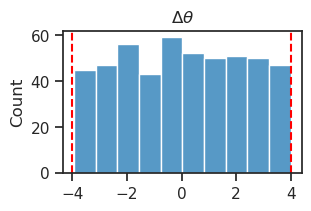

In [6]:
from main.datafeeder import RotateFeeder

vld_omni = make_dataset('Omniglot', device=tr.feeder_vld.device)[1]

feeder_omni = tr.feeder_vld.fork(
    reinit=True,
    x=vld_omni[0],
    y=vld_omni[1],
    shuffle=True,
    drop_last=True,
    batch_size=500,
)
d_thetas = feeder_omni.apply_anneal(-1)

fig, ax = create_figure()
sns.histplot(tonp(d_thetas), ax=ax)
ax.axvline(-feeder_omni.max_delta_theta, color='r', ls='--')
ax.axvline(feeder_omni.max_delta_theta, color='r', ls='--')
ax.set_title(r"$\Delta \theta$")
plt.show()

In [7]:
tr.feeder_vld.n_samples, feeder_omni.n_samples

(10000, 13180)

In [8]:
tr.feeder_vld.batch_size, feeder_omni.batch_size

(200, 500)

In [9]:
len(tr.feeder_vld), len(feeder_omni)

(50, 26)

100%|█████████████████████████████████| 26/26 [01:30<00:00,  3.49s/it]


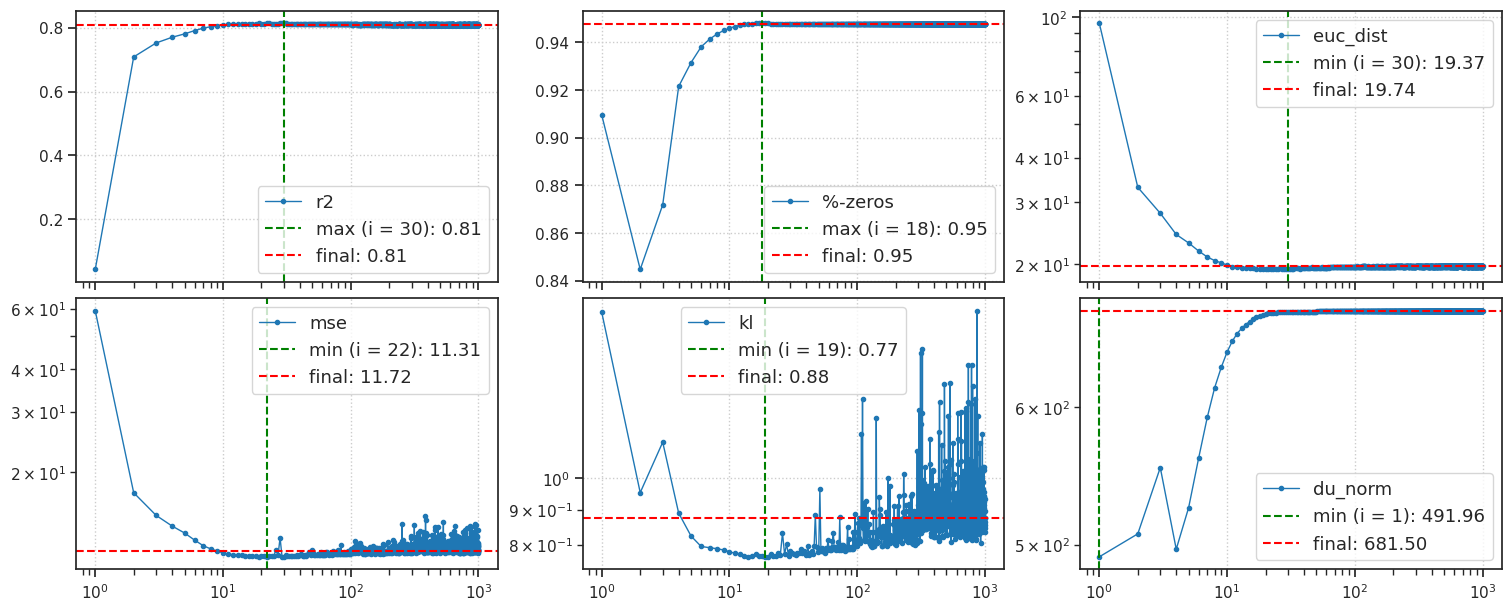

CPU times: user 1min 31s, sys: 372 ms, total: 1min 32s
Wall time: 1min 32s


In [11]:
%%time

results = tr.analysis(feeder_omni, t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

100%|█████████████████████████████████| 26/26 [02:37<00:00,  6.04s/it]


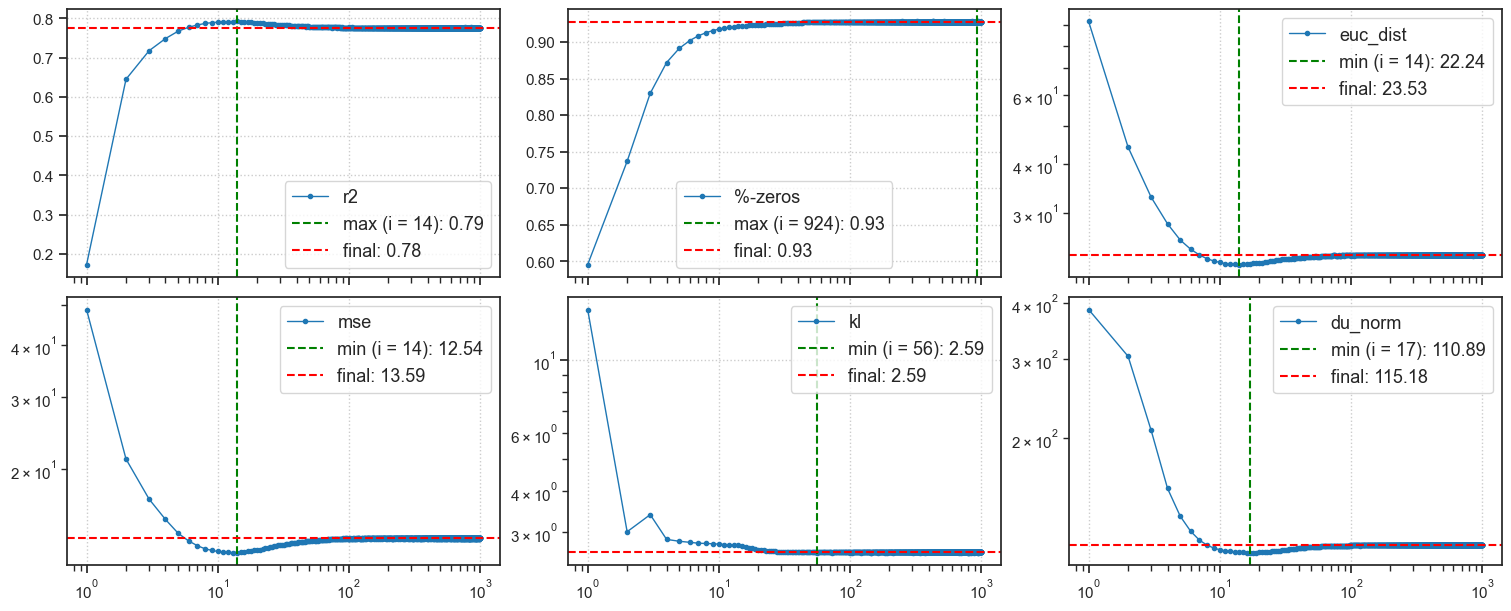

CPU times: user 2min 38s, sys: 257 ms, total: 2min 38s
Wall time: 2min 38s


In [9]:
## Was from a model trained on d_theta = 4.0 (without uniform sampling)

### xtract omni ftrs

In [10]:
%%time


output = tr.xtract_ftr(
    data=feeder_omni,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)
list(output)

CPU times: user 16.2 s, sys: 18.8 s, total: 35 s
Wall time: 35 s


['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

### save animation mp4

In [11]:
rng = get_rng(4)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)

CPU times: user 5min 11s, sys: 8.38 s, total: 5min 20s
Wall time: 5min 56s


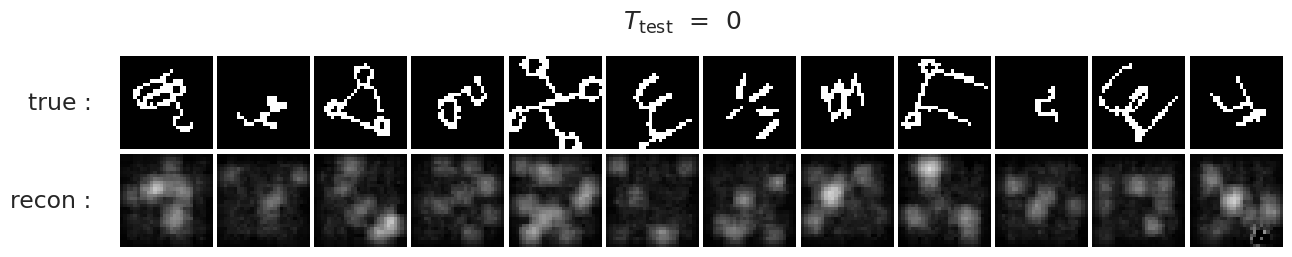

In [12]:
%%time

_ = animate_recons(
    save_file=pjoin(anim_dir, 'mnist-to-omni_rotate-uniform4'),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    n_samples=12,
    # dry_run=True,
)

## MNIST to EMNIST generalize?

### load MNIST model

In [13]:
fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_recon-mse_chewie-0_(2025_09_07,15:41)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

100

### make EMNIST feeder

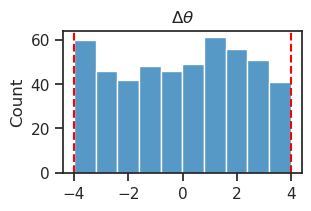

In [14]:
from main.datafeeder import RotateFeeder

vld_emnist = make_dataset('EMNIST', device=tr.feeder_vld.device)[1]

feeder_emnist = tr.feeder_vld.fork(
    reinit=True,
    x=vld_emnist[0],
    y=vld_emnist[1],
    shuffle=True,
    drop_last=True,
    batch_size=500,
)
d_thetas = feeder_emnist.apply_anneal(-1)

fig, ax = create_figure()
sns.histplot(tonp(d_thetas), ax=ax)
ax.axvline(-feeder_emnist.max_delta_theta, color='r', ls='--')
ax.axvline(feeder_emnist.max_delta_theta, color='r', ls='--')
ax.set_title(r"$\Delta \theta$")
plt.show()

In [15]:
tr.feeder_vld.n_samples, feeder_emnist.n_samples

(10000, 20800)

100%|█████████████████████████████████| 41/41 [02:24<00:00,  3.51s/it]


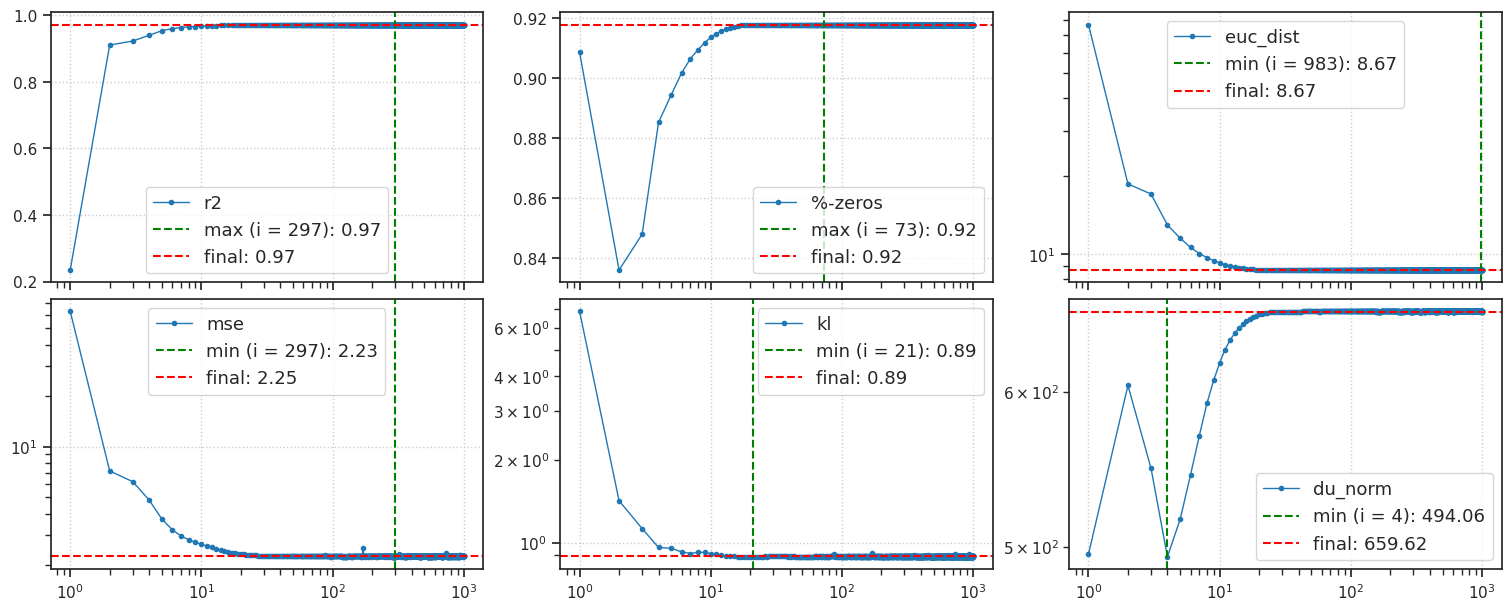

CPU times: user 2min 24s, sys: 581 ms, total: 2min 25s
Wall time: 2min 25s


In [17]:
%%time

results = tr.analysis(feeder_emnist, t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

### xtract emnist ftrs

In [18]:
%%time


output = tr.xtract_ftr(
    data=feeder_emnist,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)
list(output)

CPU times: user 14 s, sys: 16.4 s, total: 30.4 s
Wall time: 30.4 s


['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

### save animation mp4

In [19]:
rng = get_rng(1)

sample_ids = rng.choice(
    range(len(output['true'])),
    replace=False,
    size=12,
)

CPU times: user 4min 50s, sys: 8.61 s, total: 4min 59s
Wall time: 5min 32s


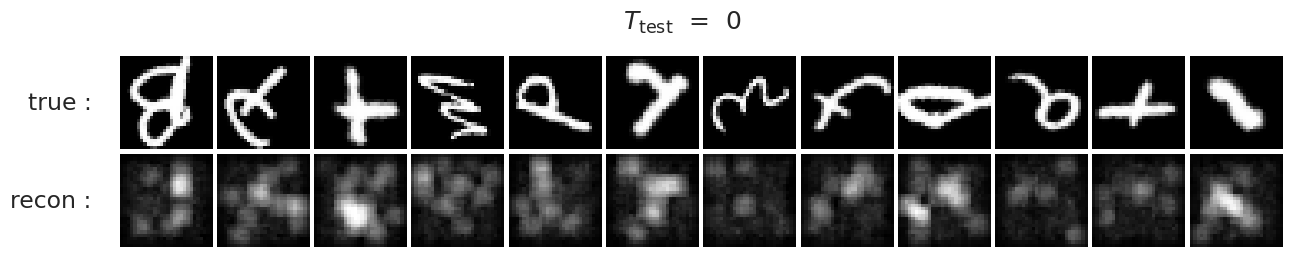

In [20]:
%%time

_ = animate_recons(
    save_file=pjoin(anim_dir, 'mnist-to-emnist_rotate-uniform4'),
    recon=output['recon'][sample_ids],
    true=output['true'][sample_ids],
    n_samples=12,
    # dry_run=True,
)